# Overture — Building footprints (live)

Fetch building footprints for a neighbourhood block and plot them. Buildings is the largest theme (2.3 B rows globally), so a **bounded bbox is required** — the backend guards against an oversized box.

In [1]:
LAT_LIM = [40.757, 40.759]  # [south, north]
LON_LIM = [-73.987, -73.984]  # [west, east] — a Times Square block
OUT = "_overture_out"

In [2]:
from earthlens.earthlens import EarthLens

paths = EarthLens(
    data_source="overture",
    variables={"buildings": []},
    lat_lim=LAT_LIM,
    lon_lim=LON_LIM,
    path=OUT,
    file_format="geoparquet",
).download()
paths

2026-05-27 14:48:02 | INFO | pyramids.base.config | Logging is configured.


2026-05-27 14:48:02.369 | INFO     | earthlens.overture.backend:_fetch:377 - Fetching Overture 'building' (theme 'buildings') for bbox (-73.987, 40.757, -73.984, 40.759) (release=latest)


C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\overture\src\earthlens\overture\collection.py:77: LicenseWarning: buildings/building: 45 of 45 feature(s) are ODbL-1.0 (OSM-derived). ODbL-1.0 carries attribution and share-alike obligations that CDLA-Permissive-2.0 does not; honour them when redistributing these rows.
  warn_if_odbl(license_ids, label)
2026-05-27 14:49:39.276 | INFO     | earthlens.overture.backend:_fetch:386 - buildings/building: wrote 45 feature(s) to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\overture\docs\examples\overture\_overture_out\overture_buildings_building_latest.parquet


[WindowsPath('C:/gdrive/algorithms/remote-sensing/earthlens/.claude/worktrees/overture/docs/examples/overture/_overture_out/overture_buildings_building_latest.parquet')]

In [3]:
import geopandas as gpd

gdf = gpd.read_parquet(paths[0])
print(len(gdf), 'footprints;  geom', gdf.geometry.geom_type.unique())
gdf[['id', 'license_id']].head()

45 footprints;  geom <ArrowStringArray>
['Polygon']
Length: 1, dtype: str


,id,license_id
0,55377c2e-20ee-4677-93a2-ee0eeeefc597,ODbL-1.0
1,0e13f41b-4f76-486c-b05e-39416acb2d39,ODbL-1.0
2,9f3a969d-fa65-4641-bcd1-d95d6d6d4f2e,ODbL-1.0
3,cc3013a1-c68d-4d19-be92-4b016cb7432b,ODbL-1.0
4,ea522641-3956-412c-b0e5-8875f03b4bf2,ODbL-1.0


A quick plot of the footprints:

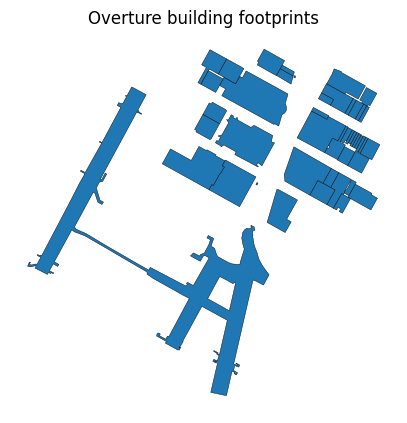

In [4]:
ax = gdf.plot(figsize=(5, 5), edgecolor='black', linewidth=0.3)
ax.set_title('Overture building footprints')
ax.set_axis_off()

The guard rejects a whole-Earth buildings request rather than trying to read billions of rows:

In [5]:
try:
    EarthLens(
        data_source="overture",
        variables={"buildings": []},
        lat_lim=[-90, 90], lon_lim=[-180, 180],
        path=OUT,
    ).download()
except ValueError as exc:
    print(exc)

The requested bbox covers 64800.00 square degrees, which exceeds the 0.50 square-degree cap for the 'buildings' theme (its global row count makes an oversized box a footgun). Shrink the bbox (lat_lim / lon_lim), pass a larger max_bbox_deg2=, or set max_features= to cap the result.
